# Ensemble Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch
import random

# Problem 1
Operate on the 'moonDataset.csv'. Separate the first 150 samples into training set and the last 50 samples into testing set.

In [ ]:
# Import CSV file
df = pd.read_csv('/content/moonDataset.csv')
print(df.describe())

# Split into training and testing set
train = df.iloc[:150]
test = df.iloc[150:]
# print(train.iloc[0])

               X1          X2          X3       label
count  200.000000  200.000000  200.000000  200.000000
mean     0.499625    0.242255   -0.007900    0.500000
std      0.864680    0.505837    0.060073    0.501255
min     -1.082877   -0.671388   -0.099842    0.000000
25%     -0.066660   -0.182419   -0.059922    0.000000
50%      0.517917    0.215962   -0.010587    0.500000
75%      1.044591    0.696222    0.040636    1.000000
max      2.148725    1.168358    0.099933    1.000000


## Part a
Construct 50 datasets of size 150 from the training dataset using the bootstrap method.

In [ ]:
# Initialize 50 empty lists to store the datasets
datasets = []

# Generate 50 datasets of size 150 from the training dataset using the bootstrap method
for i in range(50):
    # Sample with replacement from the training dataset
    bootstrap_sample = train.sample(n=150, replace=True)
    # Split into features and labels
    X_bootstrap = bootstrap_sample.iloc[:,:-1]
    y_bootstrap = bootstrap_sample.iloc[:,-1]
    # Add the dataset to the list
    datasets.append((X_bootstrap, y_bootstrap))

# print(datasets[49])

## Part b
Train 50 feedforward networks for each of the bootstrapped datasets. The networks are to have 1 hidden layer of 10 hidden nodes.

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FeedForwardNN, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU() # Linear Activation function to avoid vanishing gradient
        self.output = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid() # Binary Activation function

    def forward(self, x):
        out_theta1 = self.hidden(x)
        out_activation = self.relu(out_theta1)
        out_theta2 = self.output(out_activation)
        out_final = self.sigmoid(out_theta2)
        return out_final

# Parameters of neural network
input_size = 3
hidden_size = 10
output_size = 1
gamma = 0.05 # Learning rate

# Go through each dataset and train a model
models= []
for features, labels in datasets:

  # Convert features and labels
  features = torch.tensor(features.values, dtype=torch.float64)
  labels = torch.tensor(labels.values, dtype=torch.float64)
  # print(labels)
  # Initialize a model
  model = FeedForwardNN(input_size, hidden_size, output_size).double()

  # Loss function and optimizer
  loss_function = nn.BCELoss() # This stands for Binary Cross Entropy Loss or just Entropy Loss needed for classification problems where output is 0 or 1 - Lecture 10 Slide 7
  optimizer = optim.SGD(model.parameters(), lr=gamma) # Stochastic Gradient Descent, what was implemented by hand in homework 8

  # Training iterations
  for _ in range(50):
    # Forward pass
    outputs = model(features)
    loss = loss_function(outputs, labels.view(-1, 1))

    # Clear previous gradients and do a Backwards pass (Backpropagation)
    optimizer.zero_grad()
    loss.backward()

    # Adjust weights and bias
    optimizer.step()

  models.append(model)
# print(len(models))

Test all 50 feedforward networks and plot the error rates on a histogram.

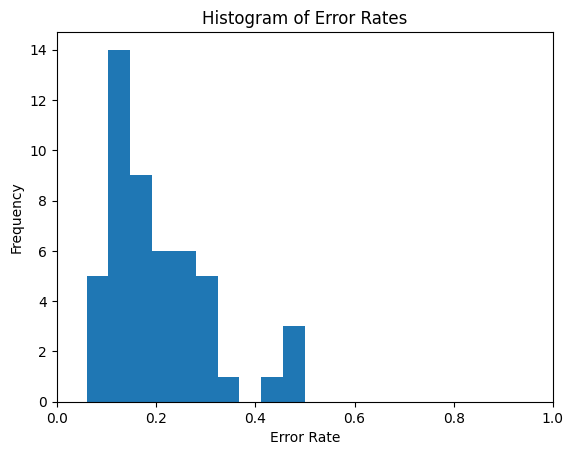

In [ ]:
def calcErrorRates(outputs, labels):
  error_rate = 0
  for res, expected in zip(outputs, labels):
    if round(res) != expected:
      error_rate += 1
  return error_rate/50 # Fixed at 50 test samples

# Split the testing data into features and labels
X_test = torch.tensor(test.iloc[:,:-1].values, dtype=torch.float64)
y_test = test.iloc[:,-1]

# Test each of the models against the testing dataset and store the error rates
error_rates = []
for model in models:
  model.eval()
  with torch.no_grad():
    # Forward pass
    outputs = model(X_test)

    # Calculate and store error rates
    outputs = [x[0] for x in outputs.tolist()]
    error_rates.append(calcErrorRates(outputs, y_test))
# print(error_rates)

# Plot the error rate on a histogram
plt.hist(error_rates, bins=10)
plt.xlim(0, 1)
plt.xlabel('Error Rate')
plt.ylabel('Frequency')
plt.title('Histogram of Error Rates')
plt.show()

## Part c
Use bagging with ensemble size (5,10,15,20).

In [ ]:
# Randomly select 5,10,15,20 models without replacement to create the bagging ensembles
ensemble_5 = random.sample(models, 5)
ensemble_10 = random.sample(models, 10)
ensemble_15 = random.sample(models, 15)
ensemble_20 = random.sample(models, 20)
ensembles = [ensemble_5, ensemble_10, ensemble_15, ensemble_20]

Test the new classifiers and plot the error rate against the ensemble size.

In [ ]:
def vote_predictions(model_predictions):
  length = len(model_predictions)
  result = []
  for i in range(len(model_predictions[0])):
    sum = 0
    for j in range(len(model_predictions)):
      sum += model_predictions[j][i]

    # Here is the part of the formula where we sum the classifications and divide by (m) to get the final resulting classification
    if sum/length >= 0.5:
      result.append(1)
    else:
      result.append(0)

  return result

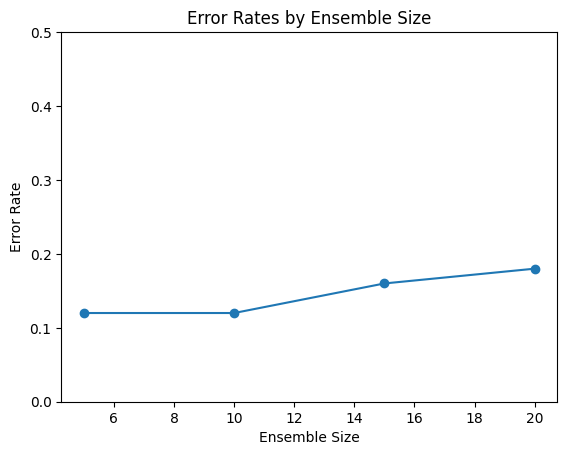

In [ ]:
# Go through the testing set and choose the classification with majority vote
error_rates_by_ensemble = []

for ensemble in ensembles:

  # Model predictions
  model_predictions = []
  for model in ensemble:
    model.eval()
    with torch.no_grad():
      # Forward pass
      outputs = model(X_test)

      # Turn list of floats into binary
      classification = [1 if res[0] > 0.5 else 0 for res in outputs.tolist()]
      model_predictions.append(classification)

  # This is the bagging step
  majority_votes = vote_predictions(model_predictions)
  error_rates_by_ensemble.append(calcErrorRates(majority_votes, y_test))

# print(error_rates_by_ensemble)

# Plot the error rates against ensemble size
plt.plot([5, 10, 15, 20], error_rates_by_ensemble, marker='o')
plt.ylim(0, 0.5)
plt.xlabel('Ensemble Size')
plt.ylabel('Error Rate')
plt.title('Error Rates by Ensemble Size')
plt.show()